In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import display, Math
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
def find_glitches(s, t=5):
    return (s.diff().abs() > t) & (s.diff(-1).abs() > t)

def clean_pipeline(df, threshold=5.0):
    df = df.copy()
    for col in ['sensor_temp_main', 'sensor_temp_backup']:
        glitches = find_glitches(df[col], threshold)
        df.loc[glitches, col] = np.nan
        df[col] = df[col].interpolate(method='time', limit_direction='both')
    return df

ckpt = torch.load('salidas/autoencoder_baseline.pt', map_location='cpu', weights_only=False)
FEATURES = ckpt['features']
W = ckpt['window']
LATENT = ckpt['latent_dim']
scaler_mean = np.asarray(ckpt['scaler_mean'])
scaler_scale = np.asarray(ckpt['scaler_scale'])

df_raw = pd.read_csv("datos/dataset_horno_sostenimiento2_CORREGIDO.csv",
                     parse_dates=['timestamp']).set_index('timestamp').sort_index()
df = clean_pipeline(df_raw)
df5 = df[FEATURES].resample('5min').mean().interpolate()
X_all = (df5.values - scaler_mean) / scaler_scale

n = len(df5)
i_train = int(n * 0.70)
i_val = int(n * 0.85)
DT = 300.0
print(f"Muestras 5min: {n} | ventana W={W} | latente={LATENT}")

Muestras 5min: 4032 | ventana W=12 | latente=8


In [3]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden=32, latent=8, window=12):
        super().__init__()
        self.window = window
        self.latent = latent
        self.encoder = nn.LSTM(n_features, hidden, batch_first=True)
        self.to_latent = nn.Linear(hidden, latent)
        self.from_latent = nn.Linear(latent, hidden)
        self.decoder = nn.LSTM(hidden, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_features)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z = self.to_latent(h[-1])
        h0 = self.from_latent(z).unsqueeze(0)
        c0 = torch.zeros_like(h0)
        dec_input = h0.transpose(0, 1).repeat(1, self.window, 1)
        out, _ = self.decoder(dec_input, (h0, c0))
        return self.head(out), z

model = LSTMAutoencoder(n_features=len(FEATURES), hidden=32, latent=LATENT, window=W)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

LSTMAutoencoder(
  (encoder): LSTM(11, 32, batch_first=True)
  (to_latent): Linear(in_features=32, out_features=8, bias=True)
  (from_latent): Linear(in_features=8, out_features=32, bias=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=11, bias=True)
)

In [4]:
def make_windows(X, W):
    m = len(X) - W + 1
    out = np.zeros((m, W, X.shape[1]))
    for i in range(m):
        out[i] = X[i:i+W]
    return out

Xw = make_windows(X_all, W)
with torch.no_grad():
    Z = np.vstack([model(torch.FloatTensor(Xw[i:i+512]))[1].numpy()
                   for i in range(0, len(Xw), 512)])

t_z = df5.index[W-1:]
y = df5['sensor_temp_main'].values[W-1:]

INPUTS = ['heater_power_pct', 'lid_open_pct', 'production_draw_rate', 'ambient_temp']
U = X_all[W-1:, [FEATURES.index(c) for c in INPUTS]]

k_train = i_train - (W - 1)
k_val = i_val - (W - 1)

z_mean, u_mean, y_mean = Z[:k_train].mean(0), U[:k_train].mean(0), y[:k_train].mean()
Zd, Ud, yd = Z - z_mean, U - u_mean, y - y_mean
print(f"Z: {Z.shape}, train: [0,{k_train}) val: [{k_train},{k_val}) test: [{k_val},{len(Z)})")

Z: (4021, 8), train: [0,2811) val: [2811,3416) test: [3416,4021)


In [5]:
def fit_dmdc(lam):
    Z0, Z1, U0 = Zd[:k_train-1], Zd[1:k_train], Ud[:k_train-1]
    X = np.hstack([Z0, U0])
    Theta = np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ Z1)
    A, B = Theta[:LATENT].T, Theta[LATENT:].T
    Xo = np.hstack([Zd[:k_train], Ud[:k_train]])
    Phi = np.linalg.solve(Xo.T @ Xo + lam * np.eye(Xo.shape[1]), Xo.T @ yd[:k_train])
    return A, B, Phi[:LATENT].reshape(1, -1), Phi[LATENT:].reshape(1, -1)

In [6]:
def rollout(A, B, C, D, z0, U_seq):
    zs = np.zeros((len(U_seq), LATENT))
    zs[0] = z0
    for k in range(len(U_seq) - 1):
        zs[k+1] = A @ zs[k] + B @ U_seq[k]
    return zs @ C.ravel() + U_seq @ D.ravel()

def eval_horizon(A, B, C, D, k_start, k_end, H):
    errs = []
    for k0 in range(k_start, k_end - H):
        errs.append(rollout(A, B, C, D, Zd[k0], Ud[k0:k0+H]) + y_mean - y[k0:k0+H])
    e = np.concatenate(errs)
    return float(np.sqrt(np.mean(e**2))), float(np.mean(np.abs(e)))

def persistencia(k0, k1, H):
    e = np.concatenate([y[k] - y[k:k+H] for k in range(k0, k1 - H)])
    return float(np.sqrt(np.mean(e**2)))

In [7]:
print(f"{'lambda':>8} {'max|eig|':>9} {'estable':>8} {'RMSE val 24h (°C)':>18}")
resultados = []
for lam in [0, 1, 10, 50, 100]:
    A_, B_, C_, D_ = fit_dmdc(lam)
    maxev = np.abs(np.linalg.eigvals(A_)).max()
    r24, _ = eval_horizon(A_, B_, C_, D_, k_train, k_val, 288)
    resultados.append((lam, maxev, r24))
    print(f"{lam:>8} {maxev:>9.4f} {str(maxev < 1):>8} {r24:>18.2f}")

LAM = min((r for r in resultados if r[1] < 1), key=lambda r: r[2])[0]
A, B, C, D = fit_dmdc(LAM)
print(f"\nlambda seleccionada = {LAM}")

  lambda  max|eig|  estable  RMSE val 24h (°C)


       0    1.0014    False              26.14


       1    0.9957     True              19.18


      10    0.9885     True              17.78
      50    0.9818     True              24.10


     100    0.9730     True              29.52

lambda seleccionada = 10


In [8]:
horizontes = [(3, '15 min'), (6, '30 min'), (12, '1 h'), (36, '3 h'), (72, '6 h'), (288, '24 h')]
rows = []
for H, label in horizontes:
    r_val = eval_horizon(A, B, C, D, k_train, k_val, H)
    r_test = eval_horizon(A, B, C, D, k_val, len(Z), H)
    rows.append([label, r_val[0], r_test[0], persistencia(k_val, len(Z), H)])
tabla = pd.DataFrame(rows, columns=['Horizonte', 'RMSE val (°C)', 'RMSE test (°C)',
                                    'Persistencia test (°C)']).round(2)
print(tabla.to_string(index=False))

Horizonte  RMSE val (°C)  RMSE test (°C)  Persistencia test (°C)
   15 min          11.34           11.56                    0.39
   30 min          12.02           11.69                    0.86
      1 h          13.19           11.95                    1.60
      3 h          15.88           12.16                    3.07
      6 h          17.45           12.16                    3.86
     24 h          17.78           12.60                    5.66


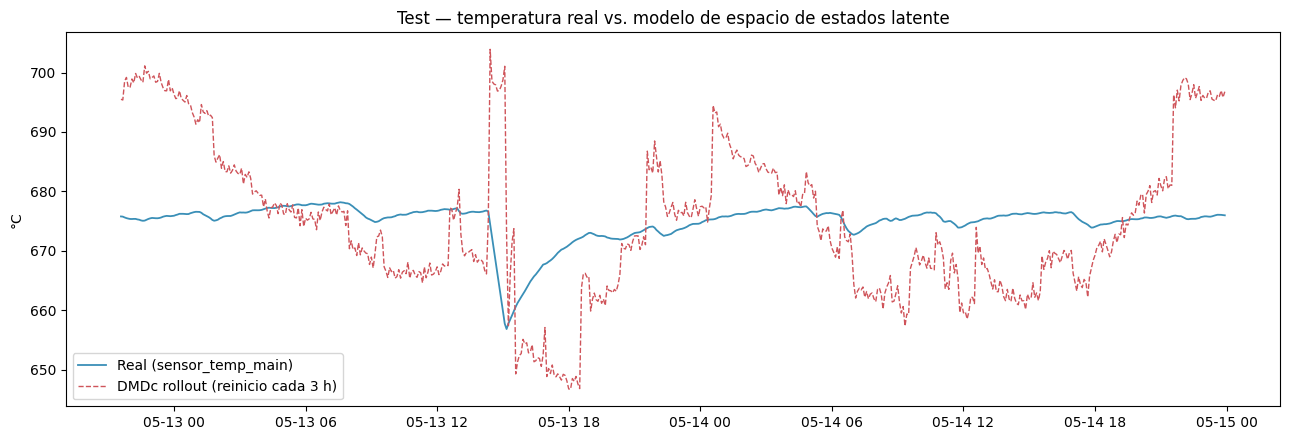

RMSE test (rollout 3 h encadenado): 12.08 °C
Desv. estándar: real = 3.15 °C | predicción = 12.62 °C


In [9]:
H = 36
y_pred_test = np.full(len(Z) - k_val, np.nan)
for k0 in range(k_val, len(Z), H):
    h = min(H, len(Z) - k0)
    y_pred_test[k0-k_val:k0-k_val+h] = rollout(A, B, C, D, Zd[k0], Ud[k0:k0+h]) + y_mean

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(t_z[k_val:], y[k_val:], color='#3a8fb7', lw=1.3, label='Real (sensor_temp_main)')
ax.plot(t_z[k_val:], y_pred_test, color='#cf545a', lw=1.0, ls='--',
        label='DMDc rollout (reinicio cada 3 h)')
ax.set_ylabel('°C'); ax.set_title('Test — temperatura real vs. modelo de espacio de estados latente')
ax.legend(); plt.tight_layout(); plt.show()
print(f"RMSE test (rollout 3 h encadenado): {np.sqrt(np.nanmean((y[k_val:] - y_pred_test)**2)):.2f} °C")
print(f"Desv. estándar: real = {y[k_val:].std():.2f} °C | predicción = {np.nanstd(y_pred_test):.2f} °C")

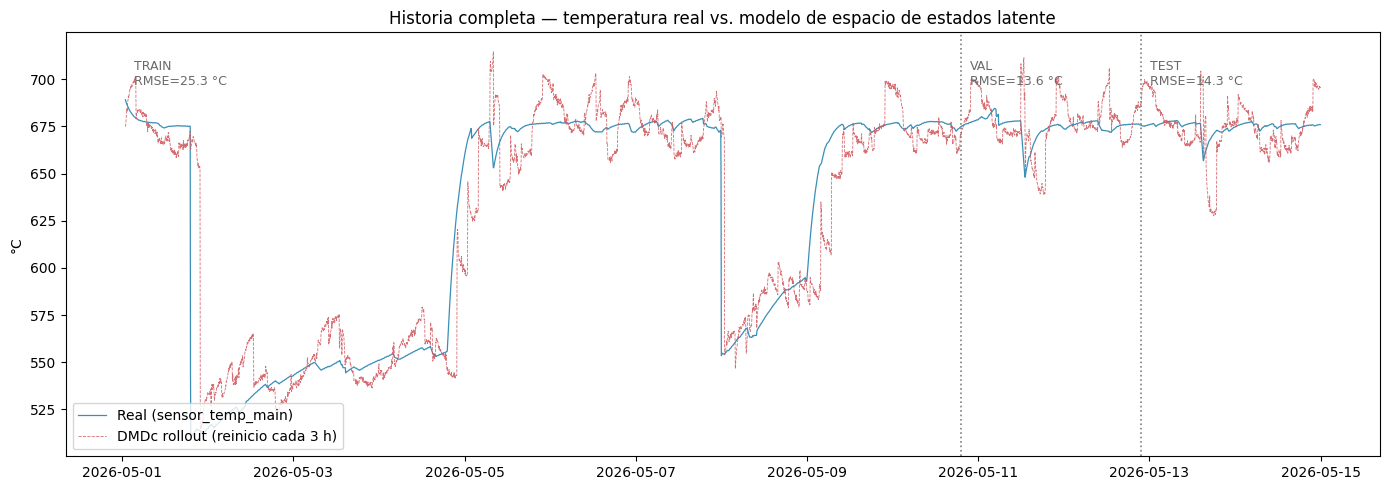

RMSE rollout 3h encadenado — train: 25.28 °C | val: 13.65 °C | test: 14.25 °C


In [10]:
H = 36
y_pred_all = np.full(len(Z), np.nan)
for k0 in range(0, len(Z), H):
    h = min(H, len(Z) - k0)
    y_pred_all[k0:k0+h] = rollout(A, B, C, D, Zd[k0], Ud[k0:k0+h]) + y_mean

rmse_split = [np.sqrt(np.nanmean((y[sl] - y_pred_all[sl])**2))
              for sl in [slice(0, k_train), slice(k_train, k_val), slice(k_val, None)]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_z, y, color='#3a8fb7', lw=0.9, label='Real (sensor_temp_main)')
ax.plot(t_z, y_pred_all, color='#cf545a', lw=0.6, ls='--', alpha=0.85,
        label='DMDc rollout (reinicio cada 3 h)')
for k, name, r in [(0, 'TRAIN', rmse_split[0]), (k_train, 'VAL', rmse_split[1]),
                   (k_val, 'TEST', rmse_split[2])]:
    if k > 0:
        ax.axvline(t_z[k], color='gray', ls=':', lw=1.2)
    ax.text(t_z[k + 30], ax.get_ylim()[1] if False else y.max() + 8,
            f'{name}\nRMSE={r:.1f} °C', fontsize=9, color='dimgray')
ax.set_ylabel('°C')
ax.set_title('Historia completa — temperatura real vs. modelo de espacio de estados latente')
ax.legend(loc='lower left'); plt.tight_layout(); plt.show()
print(f"RMSE rollout 3h encadenado — train: {rmse_split[0]:.2f} °C | "
      f"val: {rmse_split[1]:.2f} °C | test: {rmse_split[2]:.2f} °C")

Polos discretos (dt = 5 min):
  |λ|=0.9885  λ=0.9885+0.0052j  →  τ≈  432.9 min
  |λ|=0.9885  λ=0.9885-0.0052j  →  τ≈  432.9 min
  |λ|=0.9727  λ=0.9727+0.0000j  →  τ≈  180.7 min
  |λ|=0.9518  λ=0.9518+0.0000j  →  τ≈  101.2 min
  |λ|=0.8163  λ=0.8163+0.0000j  →  τ≈   24.6 min
  |λ|=0.4739  λ=0.4739+0.0000j  →  τ≈    6.7 min
  |λ|=0.4052  λ=0.4052+0.0000j  →  τ≈    5.5 min
  |λ|=0.1876  λ=0.1876+0.0000j  →  τ≈    3.0 min


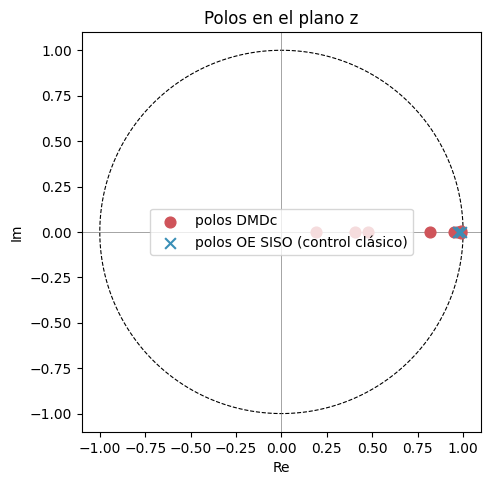

In [11]:
eig = np.linalg.eigvals(A)
eig = eig[np.argsort(-np.abs(eig))]

print("Polos discretos (dt = 5 min):")
for lam_ in eig:
    s = np.log(lam_ + 0j) / DT
    tau_min = (-1 / s.real) / 60 if s.real < 0 else np.inf
    print(f"  |λ|={abs(lam_):.4f}  λ={lam_:.4f}  →  τ≈{tau_min:7.1f} min")

fig, ax = plt.subplots(figsize=(5, 5))
th = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(th), np.sin(th), 'k--', lw=0.8)
ax.scatter(eig.real, eig.imag, s=60, color='#cf545a', zorder=5, label='polos DMDc')
ax.scatter([0.9909, 0.9724], [0, 0], s=60, marker='x', color='#3a8fb7', zorder=5,
           label='polos OE SISO (control clásico)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Re'); ax.set_ylabel('Im'); ax.set_title('Polos en el plano z')
ax.set_aspect('equal'); ax.legend(); plt.tight_layout(); plt.show()

entrada                    5min    30min       1h       3h      12h
heater_power_pct         -0.427   -0.411   -0.577   -1.373   -3.540
lid_open_pct              0.305    0.178    0.066   -0.247   -1.129
production_draw_rate     -1.168   -1.047   -0.934   -0.402    0.392
ambient_temp              5.917    6.015    4.965    1.541    1.812


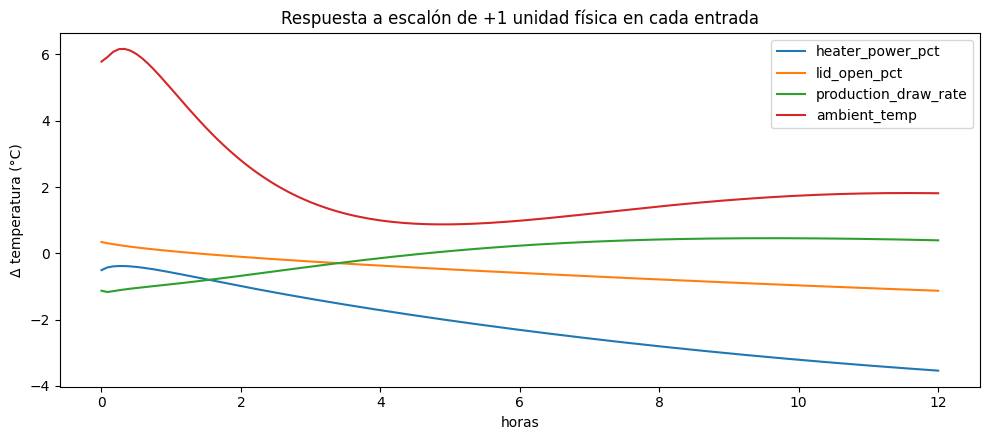

In [12]:
n_steps = 145
print(f"{'entrada':22s} {'5min':>8} {'30min':>8} {'1h':>8} {'3h':>8} {'12h':>8}")
fig, ax = plt.subplots(figsize=(10, 4.5))
t_h = np.arange(n_steps) * 5 / 60
for j, name in enumerate(INPUTS):
    u_step = np.zeros((n_steps, len(INPUTS)))
    u_step[:, j] = 1.0 / scaler_scale[FEATURES.index(name)]
    y_step = rollout(A, B, C, D, np.zeros(LATENT), u_step)
    print(f"{name:22s} {y_step[1]:8.3f} {y_step[6]:8.3f} {y_step[12]:8.3f} "
          f"{y_step[36]:8.3f} {y_step[144]:8.3f}")
    ax.plot(t_h, y_step, lw=1.5, label=name)
ax.set_xlabel('horas'); ax.set_ylabel('Δ temperatura (°C)')
ax.set_title('Respuesta a escalón de +1 unidad física en cada entrada')
ax.legend(); plt.tight_layout(); plt.show()

In [13]:
EQ_OUT = ' + D\\,u_k'
def to_latex(M, fmt='%.4f'):
    rows = [' & '.join(fmt % v for v in row) for row in np.atleast_2d(M)]
    return r'\begin{bmatrix} ' + r' \\ '.join(rows) + r' \end{bmatrix}'

display(Math(r'z_{k+1} = A\,z_k + B\,u_k \qquad y_k = C\,z_k' + EQ_OUT
             + r'\qquad (\Delta t = 5\,\text{min})'))
display(Math(r'A = ' + to_latex(A)))
display(Math(r'B = ' + to_latex(B)))
display(Math(r'C = ' + to_latex(C)))
if D.any():
    display(Math(r'D = ' + to_latex(D)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:
np.savez('salidas/dmdc_normal.npz',
         A=A, B=B, C=C, D=D, dt=DT, ridge_lambda=LAM,
         inputs=np.array(INPUTS), z_mean=z_mean, u_mean=u_mean, y_mean=y_mean,
         u_scale=np.array([scaler_scale[FEATURES.index(c)] for c in INPUTS]))
print("OK: salidas/dmdc_normal.npz guardado")

OK: salidas/dmdc_normal.npz guardado


In [15]:
from scipy import signal

j_h = INPUTS.index('heater_power_pct')
scale_h = scaler_scale[FEATURES.index('heater_power_pct')]
B_h = (B[:, [j_h]] / scale_h)
D_h = (D[:, [j_h]] / scale_h)

num_z, den_z = signal.ss2tf(A, B_h, C, D_h)
num_z = num_z.ravel()

def poly_latex(c, var='z'):
    n = len(c) - 1
    terms = []
    for i, ci in enumerate(c):
        if abs(ci) < 1e-12: continue
        p = n - i
        mono = '' if p == 0 else (var if p == 1 else f'{var}^{{{p}}}')
        terms.append(f"{ci:+.4g}\\,{mono}" if mono else f"{ci:+.4g}")
    return ' '.join(terms).lstrip('+')

display(Math(r'G(z) = \frac{' + poly_latex(num_z) + r'}{' + poly_latex(den_z) + r'} \qquad (\Delta t = 5\,\text{min},\ ^{\circ}\text{C}/\%)'))

zeros, poles = np.roots(num_z), np.roots(den_z)
print(f"G(1) = {np.polyval(num_z, 1.0)/np.polyval(den_z, 1.0):+.3f} °C/%")
print(f"max|polo| = {np.abs(poles).max():.4f} | max|cero| = {np.abs(zeros).max():.4f}")

<IPython.core.display.Math object>

G(1) = -4.534 °C/%
max|polo| = 0.9885 | max|cero| = 0.9811


In [16]:
from scipy import linalg

Wc = linalg.solve_discrete_lyapunov(A, B @ B.T)
Wo = linalg.solve_discrete_lyapunov(A.T, C.T @ C)
Lc = linalg.cholesky(Wc, lower=True)
ev, V = linalg.eigh(Lc.T @ Wo @ Lc)
order = np.argsort(-ev)
hsv = np.sqrt(np.maximum(ev[order], 0))
V = V[:, order]
T = Lc @ V @ np.diag(hsv**-0.5)
Tinv = np.diag(hsv**0.5) @ V.T @ linalg.inv(Lc)

R = 2
Ar, Br, Cr = (Tinv @ A @ T)[:R, :R], (Tinv @ B_h)[:R, :], (C @ T)[:, :R]
num2, den2 = signal.ss2tf(Ar, Br, Cr, D_h)
num2 = num2.ravel()

display(Math(r'G_2(z) = \frac{' + poly_latex(num2) + r'}{' + poly_latex(den2) + r'}'))
display(Math(r'G(s) = \frac{-0.4667\,s + 3.11\cdot 10^{-3}}'
             r'{s^2 + 7.33\cdot 10^{-3}\,s + 4.44\cdot 10^{-6}}'))

p2 = np.roots(den2)
s2 = np.log(p2.astype(complex)) / DT
print(f"G2(z): polos {p2.round(4)} | tau = {(-1/s2.real/60).round(1)} min")
print("G(s):  polos -6.66e-4, -6.66e-3 1/s | tau = 25.0 y 2.5 min")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

G2(z): polos [0.9885+0.0083j 0.9885-0.0083j] | tau = [434.6 434.6] min
G(s):  polos -6.66e-4, -6.66e-3 1/s | tau = 25.0 y 2.5 min


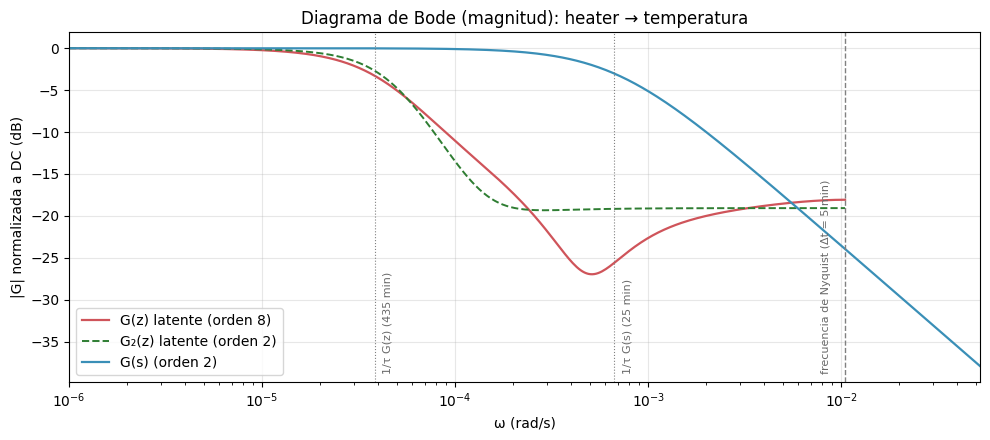

In [17]:
w_nyq = np.pi / DT
w = np.logspace(-6, np.log10(w_nyq), 400)
w_s = np.logspace(-6, np.log10(w_nyq) + 0.7, 500)

_, mag_z, _ = signal.dbode((num_z, den_z, DT), w=w*DT)
_, mag_z2, _ = signal.dbode((num2, den2, DT), w=w*DT)
_, mag_s, _ = signal.bode(([-0.4667, 3.11e-3], [1, 7.33e-3, 4.44e-6]), w=w_s)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.semilogx(w, mag_z - mag_z[0], color='#cf545a', lw=1.6, label='G(z) latente (orden 8)')
ax.semilogx(w, mag_z2 - mag_z2[0], color='#2e7d32', lw=1.4, ls='--', label='G₂(z) latente (orden 2)')
ax.semilogx(w_s, mag_s - mag_s[0], color='#3a8fb7', lw=1.6, label='G(s) (orden 2)')
ax.axvline(w_nyq, color='gray', ls='--', lw=1.0)
ymin, ymax = ax.get_ylim()
ax.text(w_nyq*0.85, ymin + 1, 'frecuencia de Nyquist (Δt = 5 min)', fontsize=8,
        color='dimgray', rotation=90, va='bottom', ha='right')
for tau_min, name in [(435, 'G(z)'), (25, 'G(s)')]:
    ax.axvline(1/(tau_min*60), color='gray', ls=':', lw=0.8)
    ax.text(1/(tau_min*60)*1.1, ymin + 1, f'1/τ {name} ({tau_min} min)', fontsize=8,
            color='dimgray', rotation=90, va='bottom')
ax.set_xlim(1e-6, w_nyq*5)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('ω (rad/s)'); ax.set_ylabel('|G| normalizada a DC (dB)')
ax.set_title('Diagrama de Bode (magnitud): heater → temperatura')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()